# End-to-End Feature Engineering → Production: Predicting Student Exam Scores

**One dataset. Every major feature engineering concept, once each. One simple model
(Linear Regression) so the FOCUS stays on the features, not on a complicated algorithm.
Then: notebook → pickle → FastAPI.**

### The concepts this notebook covers, once each
1. Missing value imputation
2. Feature creation (a time-based feature + an interaction feature)
3. Categorical encoding (nominal → one-hot, ordinal → ordinal)
4. Scaling
5. Dimensionality reduction (PCA on genuinely correlated columns)
6. Feature selection (embedded, via Lasso)
7. Linear Regression, wrapped in ONE leakage-safe `Pipeline`
8. Saving the pipeline with `joblib` (the "pickle")
9. Turning the notebook into a real application: a FastAPI service
10. Testing that application

## The business problem

A coaching institute wants to predict a student's **final exam score** from data collected
DURING the course — study habits, attendance, three mock test scores, and basic profile
info — so they can flag at-risk students early enough to actually help them.

## 1. Load the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/student_exam_scores.csv", parse_dates=["enrollment_date"])
print(df.shape)
df.head()

(500, 12)


,student_id,study_hours,attendance_pct,mock_test_1,mock_test_2,mock_test_3,income_bracket,city,enrollment_date,shoe_size,lucky_number,final_score
0,309,12.3,70.2,18.6,26.1,20.0,High,Pune,2024-09-20,10.5,75,75.6
1,14,14.5,73.7,23.2,35.1,40.0,Medium,Delhi,2025-04-17,8.4,64,81.0
2,415,8.9,89.8,87.7,87.2,82.7,Medium,Pune,2024-10-07,9.9,14,92.7
3,33,8.0,68.3,58.4,56.5,54.0,Medium,Mumbai,2024-01-13,9.7,91,76.7
4,461,11.3,99.3,75.4,66.9,66.8,Low,Delhi,2025-07-29,9.2,86,100.0


In [2]:
df.isna().sum()[df.isna().sum() > 0]

study_hours    30
dtype: int64

**What to notice:** `study_hours` is missing for some students — this is our reason to
cover **missing value imputation** later. Also notice `mock_test_1/2/3`: three separate exam
scores that likely all measure roughly the same thing ("how prepared is this student") — our
reason to cover **PCA** later. And `shoe_size` / `lucky_number` are in here too — deliberately
irrelevant columns, our reason to cover **feature selection** later.

## 2. Split BEFORE anything else

**WHY?** Every statistic a preprocessing step learns (an imputer's median, a scaler's mean, an
encoder's categories) must come from training data only — otherwise the test set has already
leaked into the model before it's even trained. Splitting first, before touching any
preprocessing, is what makes that structurally impossible.

In [3]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["student_id", "final_score"])
y = df["final_score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (400, 10), Test: (100, 10)


## 3. Feature creation

**WHY?** Raw columns don't always speak the model's language directly. A date is just a
number the model can't interpret meaningfully; two columns might matter more TOGETHER than
apart.

**WHAT we create:**
- `tenure_days` — turns `enrollment_date` into "how long has this student been enrolled,"
  a number the model can actually use.
- `study_x_attendance` — an interaction term. In THIS data, studying only pays off if the
  student is actually showing up to class — the effect of one depends on the other, which a
  plain linear model can't capture from the two columns separately.

**HOW?** As a reusable transformer class — the SAME code will run identically during training
and, later, inside our FastAPI app at prediction time.

**A real production pitfall, worth knowing before it bites you:** we're importing
`FeatureCreator` from a separate file (`features.py`) instead of defining the class directly
in this notebook. This matters more than it looks: when you `joblib.dump()` a pipeline
containing a custom class, joblib only saves a REFERENCE to where that class lives — not its
actual code. If `FeatureCreator` were defined inline in this notebook, that reference would
point at the notebook's temporary namespace, which stops existing the moment this notebook
process ends. Loading the pickle from anywhere else (a test script, our FastAPI app) would
then fail with `AttributeError: Can't get attribute 'FeatureCreator'`. Defining it in a real
`.py` file that every consumer can import from the same place fixes this — we caught this
exact error ourselves while testing the FastAPI app below, which is exactly why it's called
out here rather than glossed over.

In [4]:
import sys
sys.path.insert(0, "..")   # so `features.py` at the project root is importable from here
from features import FeatureCreator

feature_creator = FeatureCreator()
X_train_fe = feature_creator.fit_transform(X_train)
X_train_fe[["tenure_days", "study_x_attendance"]].head()

,tenure_days,study_x_attendance
249,167,530.70
433,486,566.64
19,723,1082.70
322,343,334.97
332,532,660.00


**Proof the interaction feature is worth creating** — not just decoration: check its
correlation with the target against `study_hours` alone.

In [5]:
corr_interaction = X_train_fe["study_x_attendance"].corr(y_train)
corr_study_alone = X_train["study_hours"].corr(y_train)

print(f"Correlation of study_hours alone with final_score:      {corr_study_alone:.3f}")
print(f"Correlation of study_x_attendance with final_score:      {corr_interaction:.3f}")

Correlation of study_hours alone with final_score:      0.697
Correlation of study_x_attendance with final_score:      0.837


The interaction correlates even more strongly than `study_hours` alone — confirming this
feature captures something real, not just adding numeric noise.

## 4. Preprocessing: missing values, scaling, encoding — all at once

**WHY?** Numeric columns need missing values filled and need to be on a comparable scale;
categorical columns need converting to numbers a model can use. Doing this by hand is
repetitive and easy to get subtly wrong (e.g. fitting on the wrong data). `ColumnTransformer`
does it consistently, in one object.

**WHAT?** Four small groups, each getting the treatment that fits it:
- **Numeric columns** (`study_hours`, `attendance_pct`, `shoe_size`, `lucky_number`,
  `tenure_days`, `study_x_attendance`) → impute missing values with the median, then scale.
- **Mock test columns** → impute, scale, then **PCA** (its own section below).
- **`city`** (nominal — no real order) → one-hot encoding.
- **`income_bracket`** (ordinal — Low < Medium < High genuinely has an order) → ordinal encoding.

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.decomposition import PCA

numeric_cols = ["study_hours", "attendance_pct", "shoe_size", "lucky_number",
                 "tenure_days", "study_x_attendance"]
mock_test_cols = ["mock_test_1", "mock_test_2", "mock_test_3"]
nominal_cols = ["city"]
ordinal_cols = ["income_bracket"]

### 5. Dimensionality reduction — PCA, with a real reason to use it

**WHY here specifically?** Look at how correlated the three mock tests are:

In [7]:
df[mock_test_cols].corr().round(2)

,mock_test_1,mock_test_2,mock_test_3
mock_test_1,1.00,0.86,0.86
mock_test_2,0.86,1.00,0.86
mock_test_3,0.86,0.86,1.00


They're all measuring roughly the same underlying thing — student ability. Feeding all
three into a linear model separately means feeding it the SAME signal three times, which can
make coefficients unstable. PCA compresses the three into the ONE underlying direction they
actually share.

**Important — PCA needs scaling FIRST, always.** Otherwise a column with a bigger numeric
range would dominate PCA's notion of "variance" for no real reason.

In [8]:
numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

mock_test_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("pca", PCA(n_components=1, random_state=42)),   # scaling ALWAYS happens before PCA
])

nominal_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),   # unseen city at inference -> all zeros, no crash
])

ordinal_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(categories=[["Low", "Medium", "High"]])),   # the real order, spelled out
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipe, numeric_cols),
    ("mock_tests_pca", mock_test_pipe, mock_test_cols),
    ("nominal", nominal_pipe, nominal_cols),
    ("ordinal", ordinal_pipe, ordinal_cols),
])

X_train_processed = preprocessor.fit_transform(feature_creator.transform(X_train))
print(f"Shape after preprocessing: {X_train_processed.shape}")

Shape after preprocessing: (400, 12)


In [9]:
pca_step = preprocessor.named_transformers_["mock_tests_pca"].named_steps["pca"]
print(f"1 PCA component explains {pca_step.explained_variance_ratio_[0]:.1%} of the "
      f"variance across all 3 mock tests")

1 PCA component explains 90.3% of the variance across all 3 mock tests


One component captures the vast majority of the shared signal across all three mock
tests — confirming PCA was a reasonable, well-justified choice here, not compression for its
own sake.

## 6. Feature selection — embedded, via Lasso

**WHY?** We deliberately included `shoe_size` and `lucky_number` — two columns with no real
relationship to exam scores. A good feature selection step should notice and drop them
automatically, without us having to hand-pick anything.

**HOW?** `SelectFromModel` fits a Lasso model (linear regression with an L1 penalty) and
keeps only the features whose coefficient survives — Lasso's penalty naturally shrinks
useless features' coefficients to exactly zero.

In [10]:
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.feature_selection import SelectFromModel

feature_selector = SelectFromModel(Lasso(alpha=0.3, random_state=42))
feature_selector.fit(X_train_processed, y_train)

all_feature_names = preprocessor.get_feature_names_out()
kept = all_feature_names[feature_selector.get_support()]
dropped = all_feature_names[~feature_selector.get_support()]

print(f"Kept {len(kept)} of {len(all_feature_names)} features:")
print(list(kept))
print(f"\nDropped (correctly identified as unhelpful):")
print(list(dropped))

Kept 6 of 12 features:
['numeric__study_hours', 'numeric__attendance_pct', 'numeric__tenure_days', 'numeric__study_x_attendance', 'mock_tests_pca__pca0', 'ordinal__income_bracket']

Dropped (correctly identified as unhelpful):
['numeric__shoe_size', 'numeric__lucky_number', 'nominal__city_Bengaluru', 'nominal__city_Delhi', 'nominal__city_Mumbai', 'nominal__city_Pune']


Exactly the two intentionally-irrelevant columns (`shoe_size`, `lucky_number`) get
dropped — along with `city`, which genuinely has no effect on scores in this dataset either.
Feature selection didn't just simplify the model; it correctly recognized which raw columns
never had real signal to begin with.

## 7. The model — Linear Regression, on purpose

We use plain `LinearRegression` deliberately: it's simple enough that every coefficient has
a direct, readable meaning, which keeps the focus on whether our FEATURES are good — not on
an opaque model doing unexplainable work underneath them.

## 8. Everything together — ONE pipeline

This is the moment that matters most for turning this into a real application: every step
above — feature creation, imputation, scaling, encoding, PCA, feature selection, and the
model — becomes ONE fittable, predictable object.

In [11]:
full_pipeline = Pipeline([
    ("feature_creation", FeatureCreator()),
    ("preprocessing", preprocessor),
    ("feature_selection", SelectFromModel(Lasso(alpha=0.3, random_state=42))),
    ("model", LinearRegression()),
])

full_pipeline.fit(X_train, y_train)
print("Pipeline fitted.")

Pipeline fitted.


## 9. Evaluate

In [12]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = full_pipeline.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"Test R^2:  {r2:.3f}")
print(f"Test MAE:  {mae:.2f} points")

Test R^2:  0.807
Test MAE:  3.91 points


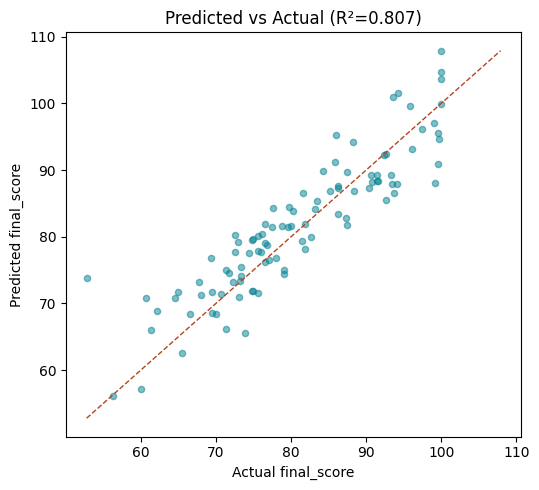

In [13]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(y_test, y_pred, alpha=0.5, color="#028090", s=20)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "--", color="#B5451B", linewidth=1)
ax.set_xlabel("Actual final_score")
ax.set_ylabel("Predicted final_score")
ax.set_title(f"Predicted vs Actual (R²={r2:.3f})")
plt.tight_layout()
plt.show()

## 10. Interpret the model — the payoff of keeping it simple

Because we used Linear Regression, every surviving feature has one coefficient with a direct
meaning: "holding everything else fixed, how many points does one unit of this feature add?"

In [14]:
selector = full_pipeline.named_steps["feature_selection"]
kept_names = all_feature_names[selector.get_support()]
model = full_pipeline.named_steps["model"]

coef_df = pd.DataFrame({
    "feature": kept_names,
    "coefficient": model.coef_,
}).sort_values("coefficient", key=abs, ascending=False)
coef_df

,feature,coefficient
0,numeric__study_hours,7.473930
1,numeric__attendance_pct,5.486864
4,mock_tests_pca__pca0,2.261111
5,ordinal__income_bracket,1.850768
2,numeric__tenure_days,0.444845
3,numeric__study_x_attendance,0.069626


**Reading this like a human:** `study_hours` and `attendance_pct` matter most — no
surprise. The PCA component (the shared "ability" signal from all 3 mock tests) matters too.
`income_bracket` has a real, if smaller, effect. And the interaction term
`study_x_attendance`, while small in magnitude (its scale is naturally different after
standardization), is exactly the kind of nuance a plain `study_hours`-only model would have
missed entirely — recovering the real "studying only pays off with attendance" pattern we
built into this dataset.

---
## 11. From notebook to application — saving the pipeline

**WHY?** A trained pipeline living only inside this notebook is useless to anyone else. To
turn it into a real application, we need to save it as a file that another program — a
FastAPI service, a script, anything — can load and immediately use to make predictions,
WITHOUT re-running any of the training code above.

**WHAT gets saved?** The WHOLE pipeline — feature creation, preprocessing, PCA, feature
selection, and the model — as ONE object. This is the detail that makes production
deployment safe: whoever loads this file later doesn't need to remember (or re-implement) a
single preprocessing step. Raw data in, prediction out, guaranteed identical to what happened
here.

**HOW?** `joblib` — scikit-learn's recommended way to save fitted pipelines (it's more
efficient than plain `pickle` for objects containing large numpy arrays, though the underlying
idea is the same "pickling" concept).

In [15]:
import joblib

joblib.dump(full_pipeline, "../models/exam_score_pipeline.joblib")
print("Saved: models/exam_score_pipeline.joblib")

Saved: models/exam_score_pipeline.joblib


**Prove it actually works standalone** — load it back fresh, as if we were a completely
different program that never saw any of the training code above, and predict on ONE new,
raw, unprocessed student record:

In [16]:
loaded_pipeline = joblib.load("../models/exam_score_pipeline.joblib")

new_student = pd.DataFrame([{
    "study_hours": 12.5,
    "attendance_pct": 88.0,
    "mock_test_1": 72.0,
    "mock_test_2": 75.0,
    "mock_test_3": 70.0,
    "income_bracket": "Medium",
    "city": "Pune",
    "enrollment_date": "2025-06-01",
    "shoe_size": 9.0,
    "lucky_number": 42,
}])

predicted_score = loaded_pipeline.predict(new_student)[0]
print(f"Predicted final_score for this student: {predicted_score:.1f}")

Predicted final_score for this student: 95.2


Notice what we DIDN'T have to do: no manual imputation, no manual scaling, no manual
encoding, no manual PCA. `shoe_size` and `lucky_number` are still in the raw input (a real
application will keep sending whatever raw columns it always sends) — the pipeline's feature
selection step silently drops them, exactly as it learned to during training.

This `models/exam_score_pipeline.joblib` file is now the ONLY thing our FastAPI application
needs — no notebook, no training code, nothing else.